# Notebook 5: Serie nacional mensual — mtys × ERA5 (cruce corregido)

Cruza la serie histórica nacional mensual de incendios de **mtys** (`6.- Ocurrencia Nacional...
1985-2024.xls`, 480 meses) con el **clima real de todo Chile** ya calculado por ERA5
(`monthly_mean_spatial` / `monthly_total_spatial`, promedio ponderado por área sobre todo el
dominio) — no el clima de un solo punto en Santiago que usaba la v1 de mtys.

**Por qué este cruce y no otro:** la serie de mtys (1985-2024) es la única que da tendencia
histórica larga; el cruce evento-a-evento de Javiera (notebooks 03/04) solo cubre 2010-2019
porque esa es la cobertura de la fuente CONAF que se usó. Este notebook no reemplaza esos dos
— da el **contexto nacional de largo plazo**, con el defecto de fondo de mtys (clima de un
solo punto) corregido.

**Restricción dura:** ERA5 en estos archivos solo cubre 2000-2025. Los meses de mtys
anteriores a 2000 (1985-1999, ~15 años) se muestran en el gráfico histórico como contexto,
pero **no entran al cruce con clima ni al modelo** — no hay con qué cruzarlos.

**Decisión de alcance (confirmada con el equipo):** se hace el cruce de clima + EDA/correlación
de forma honesta (esto no es opcional) y **además** se reentrena un modelo, pero con un control
explícito anti-extrapolación — la v1 de mtys predijo 43 incendios para julio 2026 cuando el
máximo histórico de julio es 24, sin ninguna advertencia. Ese bug no se repite acá.


## 1. Montar Google Drive

In [7]:
!rm -rf /content/drive

In [8]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Instalar librerías

In [9]:
!pip install -q xlrd xarray netCDF4 xgboost
print('✓ Librerías instaladas')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 90.3 MB/s eta 0:00:00
✓ Librerías instaladas


## 3. Configuración — EDITA las rutas antes de correr

In [10]:
import os

# ⚠️ EDITA: misma carpeta base de los notebooks anteriores
DRIVE_BASE = '/content/drive/MyDrive/BigDataSIC'

# Sube también el archivo 6 de mtys a tu Drive (o a una subcarpeta mtysproject/)
PATH_MTYS_MENSUAL = f'{DRIVE_BASE}/6.- Ocurrencia Nacional de Incendios Forestales según Mes, 1985 - 2024_octubre.xls'
PATH_ERA5_T2M = f'{DRIVE_BASE}/era5_t2m_chile_2000_2025.nc'
PATH_ERA5_TP  = f'{DRIVE_BASE}/era5_tp_chile_2000_2025.nc'

OUTPUT_DIR = f'{DRIVE_BASE}/datos_procesados'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('mtys mensual :', PATH_MTYS_MENSUAL)
print('ERA5 t2m     :', PATH_ERA5_T2M)
print('ERA5 tp      :', PATH_ERA5_TP)


mtys mensual : /content/drive/MyDrive/BigDataSIC/6.- Ocurrencia Nacional de Incendios Forestales según Mes, 1985 - 2024_octubre.xls
ERA5 t2m     : /content/drive/MyDrive/BigDataSIC/era5_t2m_chile_2000_2025.nc
ERA5 tp      : /content/drive/MyDrive/BigDataSIC/era5_tp_chile_2000_2025.nc


## 4. Parsear la serie nacional mensual de mtys (1985-2024)

Misma lógica de parseo ya validada en `mtysproject/incendios_chile_ml.ipynb` (celda 4):
extrae año/mes/n_incendios desde la tabla cruzada temporada×mes del archivo CONAF.


In [11]:
import pandas as pd
import numpy as np
import re

df6_raw = pd.read_excel(PATH_MTYS_MENSUAL, engine='xlrd', header=None)

temporadas = df6_raw.iloc[8, 1:41].tolist()
datos      = df6_raw.iloc[9:21, 1:41].values
meses_raw  = df6_raw.iloc[9:21, 0].tolist()

meses_map = {
    'JULIO':7, 'AGOSTO':8, 'SEPTIEMBRE':9, 'OCTUBRE':10,
    'NOVIEMBRE':11, 'DICIEMBRE':12, 'ENERO':1, 'FEBRERO':2,
    'MARZO':3, 'ABRIL':4, 'MAYO':5, 'JUNIO':6
}

def parse_anio_inicio(temp_raw):
    if hasattr(temp_raw, 'year'):
        return temp_raw.year
    t = str(temp_raw).strip()
    match = re.match(r'(\d+)[-/](\d+)', t)
    if match:
        yy = int(match.group(1).strip().zfill(2))
        return 1900 + yy if yy > 50 else 2000 + yy
    solo = re.sub(r'\D', '', t)
    if solo:
        n = int(solo)
        if n > 1900:
            return n
        return 1900 + n if n > 50 else 2000 + n
    return None

registros = []
for i, mes in enumerate(meses_raw):
    mes_clean = str(mes).strip().upper()
    if mes_clean == 'TOTAL' or mes_clean not in meses_map:
        continue
    num_mes = meses_map[mes_clean]
    for j, temp in enumerate(temporadas):
        ini = parse_anio_inicio(temp)
        if ini is None:
            continue
        anio = ini + 1 if num_mes <= 6 else ini
        n = datos[i, j]
        if pd.notna(n):
            registros.append({'anio': anio, 'mes': num_mes, 'mes_nombre': mes_clean, 'n_incendios': int(n)})

df_mensual = pd.DataFrame(registros).sort_values(['anio', 'mes']).reset_index(drop=True)
print(f'✓ Serie nacional mensual: {df_mensual.shape[0]} meses · {df_mensual.anio.min()}-{df_mensual.anio.max()}')


✓ Serie nacional mensual: 480 meses · 1984-2024


## 5. Clima nacional real desde ERA5 (spatial, no Santiago)

`monthly_mean_spatial` (t2m) y `monthly_total_spatial` (tp) ya son el promedio ponderado por
área sobre todo el dominio de Chile — exactamente "el clima nacional", calculado en
`era5_extraccion_unified.ipynb`. Se reutilizan tal cual, sin volver a tocar el grid completo.


In [12]:
import xarray as xr

ds_t2m = xr.open_dataset(PATH_ERA5_T2M)
ds_tp  = xr.open_dataset(PATH_ERA5_TP)

t2m_nacional = ds_t2m['monthly_mean_spatial'].to_series().rename('t2m_nacional')
tp_nacional  = ds_tp['monthly_total_spatial'].to_series().rename('tp_nacional')

df_clima_nacional = pd.concat([t2m_nacional, tp_nacional], axis=1).reset_index()
df_clima_nacional = df_clima_nacional.rename(columns={'time_month': 'fecha_mes'})
df_clima_nacional['anio'] = df_clima_nacional['fecha_mes'].dt.year
df_clima_nacional['mes']  = df_clima_nacional['fecha_mes'].dt.month

print(f'✓ Clima nacional ERA5: {df_clima_nacional.shape[0]} meses · '
      f'{df_clima_nacional.anio.min()}-{df_clima_nacional.anio.max()}')
df_clima_nacional.head()


✓ Clima nacional ERA5: 312 meses · 2000-2025


,fecha_mes,t2m_nacional,tp_nacional,anio,mes
0,2000-01-01,15.454837,73.606377,2000,1
1,2000-02-01,15.315384,62.704159,2000,2
2,2000-03-01,14.088251,57.750008,2000,3
3,2000-04-01,12.516860,58.150024,2000,4
4,2000-05-01,9.735901,49.971584,2000,5


## 6. Climatología y anomalía nacional

Anomalía = valor del mes menos el promedio histórico (2000-2025) de ese mismo mes calendario,
calculada sobre la serie ya promediada espacialmente — ¿fue este mes más caliente/seco de lo
normal para *ese mes del año*, a nivel país?


In [13]:
clima_por_mes = df_clima_nacional.groupby('mes')[['t2m_nacional', 'tp_nacional']].transform('mean')
df_clima_nacional['t2m_anomaly_nacional'] = df_clima_nacional['t2m_nacional'] - clima_por_mes['t2m_nacional']
df_clima_nacional['tp_anomaly_nacional']  = df_clima_nacional['tp_nacional']  - clima_por_mes['tp_nacional']

print('✓ Anomalías nacionales calculadas')
df_clima_nacional[['fecha_mes', 't2m_nacional', 't2m_anomaly_nacional', 'tp_nacional', 'tp_anomaly_nacional']].tail()


✓ Anomalías nacionales calculadas


,fecha_mes,t2m_nacional,t2m_anomaly_nacional,tp_nacional,tp_anomaly_nacional
307,2025-08-01,8.658069,0.416800,52.459198,-14.000816
308,2025-09-01,10.166735,0.669296,53.059471,1.310017
309,2025-10-01,11.726027,0.499343,59.439022,4.900734
310,2025-11-01,13.762916,0.706838,42.455769,-10.202946
311,2025-12-01,15.395252,0.575720,63.421085,4.728992


## 7. Cruce mtys × ERA5

Se une por año+mes. Los meses de mtys anteriores a 2000 quedan fuera del cruce (no hay ERA5
para esos años) — se cuentan explícitamente para que quede claro cuánto de la serie histórica
se pierde al exigir clima real.


In [14]:
df_cruzado = df_mensual.merge(df_clima_nacional, on=['anio', 'mes'], how='inner')

meses_sin_clima = len(df_mensual) - len(df_cruzado)
print(f'Meses de mtys totales      : {len(df_mensual)} ({df_mensual.anio.min()}-{df_mensual.anio.max()})')
print(f'Meses sin clima ERA5 (<2000): {meses_sin_clima}')
print(f'✓ Meses cruzados con clima real: {len(df_cruzado)} ({df_cruzado.anio.min()}-{df_cruzado.anio.max()})')


Meses de mtys totales      : 480 (1984-2024)
Meses sin clima ERA5 (<2000): 186
✓ Meses cruzados con clima real: 294 (2000-2024)


## 8. EDA — serie histórica completa + correlación con clima real

Panel 1: serie completa 1985-2024 (contexto, sin clima) para no perder la tendencia larga.
Panel 2: correlación **solo** en el tramo con clima real (2000-2024) — comparable directamente
con los r=0.887 (temp_max) / r=-0.509 (precip) que dio la v1 de mtys con clima de Santiago.


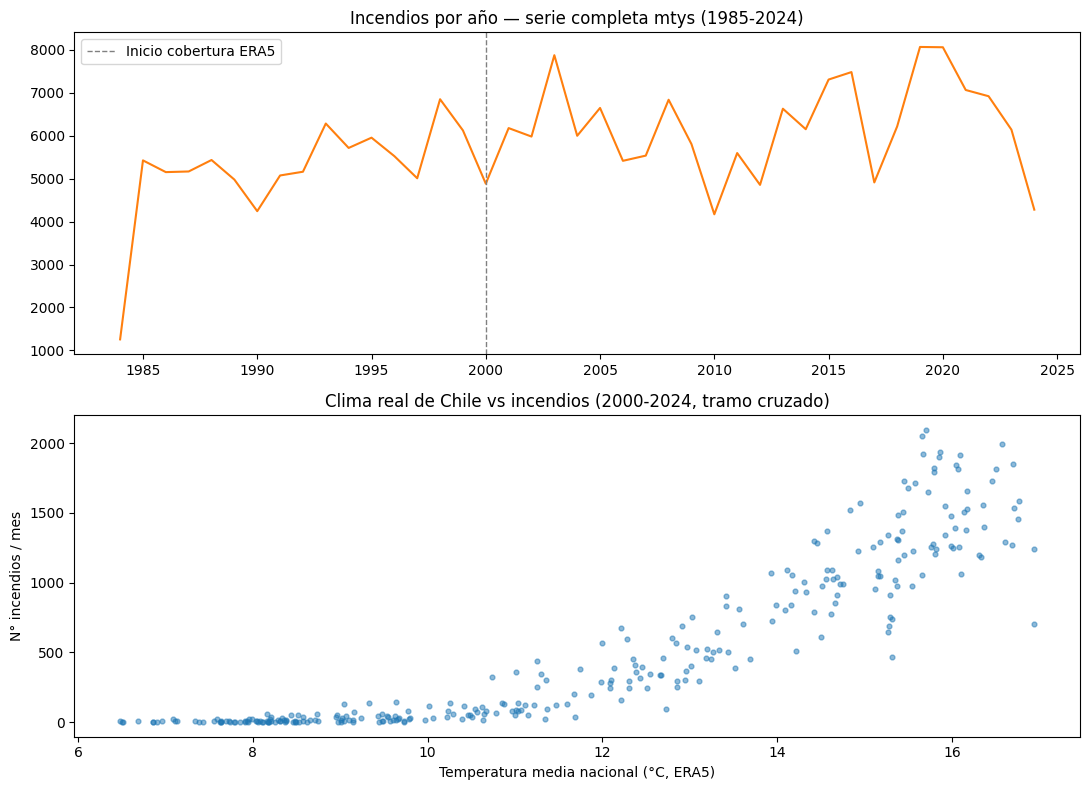

Correlación con n_incendios (tramo 2000-2024, clima ERA5 real):
n_incendios             1.000
t2m_nacional            0.894
tp_nacional            -0.179
t2m_anomaly_nacional    0.058
tp_anomaly_nacional    -0.082
Name: n_incendios, dtype: float64


In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(11, 8))

anual_completo = df_mensual.groupby('anio')['n_incendios'].sum()
axes[0].plot(anual_completo.index, anual_completo.values, color='tab:orange')
axes[0].axvline(2000, color='gray', linestyle='--', lw=1, label='Inicio cobertura ERA5')
axes[0].set_title('Incendios por año — serie completa mtys (1985-2024)')
axes[0].legend()

axes[1].scatter(df_cruzado['t2m_nacional'], df_cruzado['n_incendios'], s=12, alpha=0.5)
axes[1].set_xlabel('Temperatura media nacional (°C, ERA5)')
axes[1].set_ylabel('N° incendios / mes')
axes[1].set_title('Clima real de Chile vs incendios (2000-2024, tramo cruzado)')

plt.tight_layout()
plt.show()

print('Correlación con n_incendios (tramo 2000-2024, clima ERA5 real):')
print(df_cruzado[['n_incendios', 't2m_nacional', 'tp_nacional',
                   't2m_anomaly_nacional', 'tp_anomaly_nacional']].corr()['n_incendios'].round(3))


## 9. Modelo (con control anti-extrapolación)

Mismo enfoque que mtys (XGBoost, split temporal), pero:
- Entrenado con clima real de Chile, no Santiago.
- Split acotado al tramo con clima real: train ≤2015, test 2016-2024 (dentro de 2000-2024).
- Métrica honesta: MAE y R², **sin MAPE** (con meses en 0 el MAPE se dispara y engaña, como
  pasó en la v1: 120.2%).


In [16]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

df_model = df_cruzado.copy()
df_model['mes_sin'] = np.sin(2 * np.pi * df_model['mes'] / 12)
df_model['mes_cos'] = np.cos(2 * np.pi * df_model['mes'] / 12)
df_model['es_verano'] = df_model['mes'].isin([12, 1, 2, 3]).astype(int)

FEATURES = ['mes', 'mes_sin', 'mes_cos', 'es_verano',
            't2m_nacional', 'tp_nacional', 't2m_anomaly_nacional', 'tp_anomaly_nacional', 'anio']
TARGET = 'n_incendios'

train = df_model[df_model['anio'] <= 2015]
test  = df_model[df_model['anio'] > 2015]

modelo = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
modelo.fit(train[FEATURES], train[TARGET])
pred = modelo.predict(test[FEATURES])

print(f'MAE : {mean_absolute_error(test[TARGET], pred):.0f} incendios/mes')
print(f'R²  : {r2_score(test[TARGET], pred):.3f}')
print()
print('Importancia de variables:')
print(pd.Series(modelo.feature_importances_, index=FEATURES).sort_values(ascending=False).round(3))


MAE : 123 incendios/mes
R²  : 0.891

Importancia de variables:
es_verano               0.977
t2m_nacional            0.012
mes                     0.003
tp_anomaly_nacional     0.002
anio                    0.002
t2m_anomaly_nacional    0.001
tp_nacional             0.001
mes_sin                 0.001
mes_cos                 0.001
dtype: float32


## 10. Predicción con control anti-extrapolación

Esto es lo que la v1 de mtys **no tenía**: si la predicción supera el máximo histórico de ese
mes, no se reporta como número puntual — se marca explícitamente "fuera de precedente
histórico" en vez de devolver un valor absurdo sin avisar (el bug real: julio 2026 → 43,
cuando el máximo histórico de julio es 24).


In [17]:
stats_historicas = df_model.groupby('mes')['n_incendios'].describe()

def predecir_con_control(mes, t2m_nac, tp_nac, t2m_anom, tp_anom, anio=2026):
    X_nuevo = pd.DataFrame([{
        'mes': mes,
        'mes_sin': np.sin(2 * np.pi * mes / 12),
        'mes_cos': np.cos(2 * np.pi * mes / 12),
        'es_verano': 1 if mes in [12, 1, 2, 3] else 0,
        't2m_nacional': t2m_nac,
        'tp_nacional': tp_nac,
        't2m_anomaly_nacional': t2m_anom,
        'tp_anomaly_nacional': tp_anom,
        'anio': anio,
    }])
    pred = float(modelo.predict(X_nuevo)[0])

    hist = stats_historicas.loc[mes]
    maximo = hist['max']

    print('=' * 50)
    print(f'Mes {mes} · predicción cruda del modelo: {pred:.0f}')
    print(f'Máximo histórico para este mes (1985-2024): {int(maximo)}')

    if pred > maximo:
        print('⚠️  FUERA DE PRECEDENTE HISTÓRICO — no se reporta como número puntual.')
        print('    Interpretación correcta: "riesgo extremo, sin precedente reciente registrado",')
        print('    no "se esperan N incendios".')
        return None, 'FUERA_DE_PRECEDENTE'
    else:
        p75 = hist['75%']
        nivel = 'MUY ALTO' if pred > p75 else 'NORMAL/ALTO'
        print(f'--> Estimación dentro de rango histórico: {pred:.0f} ({nivel})')
        return pred, nivel

print('Función de predicción con control lista.')


Función de predicción con control lista.


## 11. Guardar dataset nacional mensual cruzado

In [18]:
out_csv = f'{OUTPUT_DIR}/incendios_nacional_mensual_era5.csv'
df_cruzado.to_csv(out_csv, index=False)

print(f'✓ Guardado: {out_csv}')
print(f'  {len(df_cruzado)} meses (2000-2024) con clima nacional real de ERA5')
print()
print('Esta serie da el contexto/tendencia nacional de largo plazo. El detalle espacial')
print('(comuna-año, con estrés hídrico y severidad) sigue viniendo de los notebooks 03/04.')


✓ Guardado: /content/drive/MyDrive/BigDataSIC/datos_procesados/incendios_nacional_mensual_era5.csv
  294 meses (2000-2024) con clima nacional real de ERA5

Esta serie da el contexto/tendencia nacional de largo plazo. El detalle espacial
(comuna-año, con estrés hídrico y severidad) sigue viniendo de los notebooks 03/04.


## ✅ Qué corrige este notebook respecto a la v1 de mtys

- [x] Clima real de todo Chile (ERA5 spatial) en vez de un solo punto (Santiago)
- [x] Métrica de error honesta (MAE, R² — sin MAPE inflado por meses en 0)
- [x] Control explícito anti-extrapolación (no repite el error de julio 2026 = 43 > máx. histórico 24)
- [x] Transparencia sobre qué tramo de la serie (1985-1999) queda fuera del cruce por falta de clima

**Para la presentación:** este notebook es también un argumento de rigor — "detectamos un
problema en la v1, lo diagnosticamos, y lo corregimos con datos reales" es más convincente
frente al profesor que esconder la v1.
